<a href="https://colab.research.google.com/github/yunju-1118/ESAA/blob/OB/ESAA_OB_week07_2_RecommendationSystem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **추천 시스템**

## **행렬 분해를 이용한 잠재 요인 협업 필터링 실습**

In [15]:
import numpy as np

def get_rmse(R, P, Q, non_zeros):
    error = 0
    for i, j, r in non_zeros:
        pred = np.dot(P[i, :], Q[j, :].T)
        error += pow(r - pred, 2)
    rmse = np.sqrt(error / len(non_zeros))
    return rmse

행렬 분해 로직

In [18]:
def matrix_factorization(R, K, steps=200, learning_rate=0.01, r_lambda = 0.01 ):
    num_users, num_items = R.shape
    # P와 Q 매트릭스의 크기를 지정하고 정규 분포를 가진 랜덤한 값으로 입력합니다.
    np.random.seed(1)
    P = np.random.normal(scale=1./K, size=(num_users, K))
    Q = np.random.normal(scale=1./K, size=(num_items, K))

    # R 〉0 인 행 위치, 열 위치, 값을 non.zeros 리스트 객체에 저장.
    non_zeros = [ (i, j, R[i, j]) for i in range(num_users) for j in range(num_items) if R[i, j] > 0]

    # SGD기법으로 P와 Q 매트릭스를 계속 업데이트.
    for step in range(steps):
        for i, j, r in non_zeros:
            # 실제 값과 예측 값의 차이인 오류 값 구함
            eij = r - np.dot(P[i, :], Q[j, :].T)
            # Regularization을 반영한 SGD 업데이트 공식 적용
            P[i, :] = P[i, :] + learning_rate*(eij * Q[j, :] - r_lambda*P[i, :])
            Q[j, :] = Q[j, :] + learning_rate*(eij * P[i, :] - r_lambda*Q[j, :])
        rmse = get_rmse(R, P, Q, non_zeros)
        if (step % 10) == 0 :
            print("### iteration step : ", step, " rmse : ", rmse)
    return P, Q

In [6]:
import pandas as pd
import numpy as np

movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')
ratings = ratings[['userId', 'movieId', 'rating']]
ratings_matrix = ratings.pivot_table('rating', index='userId', columns='movieId')

# title 칼럼을 얻기 위해 movies와 조인 수행
rating_movies = pd.merge(ratings, movies, on='movieId')

# columns='title'로 title 칼럼으로 pivot 수행
ratings_matrix = rating_movies.pivot_table('rating', index='userId', columns='title')

In [19]:
P, Q = matrix_factorization(ratings_matrix.values, K=50, steps=200,
                            learning_rate=0.01, r_lambda=0.01)

pred_matrix = np.dot(P, Q.T)

### iteration step :  0  rmse :  2.9023619751337115
### iteration step :  10  rmse :  0.7335768591017939
### iteration step :  20  rmse :  0.5115539026853438
### iteration step :  30  rmse :  0.37261628282537734
### iteration step :  40  rmse :  0.29608182991810145
### iteration step :  50  rmse :  0.2520353192341621
### iteration step :  60  rmse :  0.22487503275269882
### iteration step :  70  rmse :  0.20685455302331512
### iteration step :  80  rmse :  0.19413418783028674
### iteration step :  90  rmse :  0.1847008200272031
### iteration step :  100  rmse :  0.17742927527209082
### iteration step :  110  rmse :  0.17165226964707506
### iteration step :  120  rmse :  0.16695181946871496
### iteration step :  130  rmse :  0.16305292191997453
### iteration step :  140  rmse :  0.159766919296796
### iteration step :  150  rmse :  0.15695986999457337
### iteration step :  160  rmse :  0.15453398186715442
### iteration step :  170  rmse :  0.1524161855107769
### iteration step :  180  rm

In [20]:
ratings_pred_matrix = pd.DataFrame(data=pred_matrix, index=ratings_matrix.index,
                                   columns = ratings_matrix.columns)

ratings_pred_matrix.head(3)

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,3.055084,4.092018,3.564130,4.502167,3.981215,1.271694,3.603274,2.333266,5.091749,3.972454,...,1.402608,4.208382,3.705957,2.720514,2.787331,3.475076,3.253458,2.161087,4.010495,0.859474
2,3.170119,3.657992,3.308707,4.166521,4.311890,1.275469,4.237972,1.900366,3.392859,3.647421,...,0.973811,3.528264,3.361532,2.672535,2.404456,4.232789,2.911602,1.634576,4.135735,0.725684
3,2.307073,1.658853,1.443538,2.208859,2.229486,0.780760,1.997043,0.924908,2.970700,2.551446,...,0.520354,1.709494,2.281596,1.782833,1.635173,1.323276,2.887580,1.042618,2.293890,0.396941


In [21]:
# 1) 사용자가 아직 보지 않은 영화 목록 뽑기
def get_unseen_movies(ratings_matrix: pd.DataFrame, user_id: int):
    """
    ratings_matrix: index=사용자, columns=영화, 값=평점(미시청은 0 또는 NaN)
    user_id: 추천 대상 사용자 ID (ratings_matrix의 인덱스와 동일 체계)
    return: 사용자가 아직 보지 않은 영화 리스트
    """
    if user_id not in ratings_matrix.index:
        raise KeyError(f"user_id {user_id}가 ratings_matrix.index에 없습니다.")

    # (Step 1) 해당 유저의 평점 벡터
    user_ratings = ratings_matrix.loc[user_id]

    # (Step 2) 본 영화: 평점이 0보다 크거나(명시적 평점) / NaN이 아닌 값
    seen_movies = user_ratings[user_ratings.fillna(0) > 0].index.tolist()

    # (Step 3) 전체 영화 목록에서 본 영화를 제외 → 안 본 영화
    total_movies = ratings_matrix.columns.tolist()
    unseen_list = [m for m in total_movies if m not in seen_movies]
    return unseen_list


# 2) 예측 평점 행렬에서 안 본 영화 중 top-N 추천 뽑기 (Series로 반환)
def recomm_movie_by_userid(pred_matrix: pd.DataFrame, user_id: int,
                           unseen_list: list, top_n: int = 10) -> pd.Series:
    """
    pred_matrix: index=사용자, columns=영화, 값=예측 평점
    user_id: 추천 대상 사용자
    unseen_list: get_unseen_movies로 얻은 미시청 영화 리스트
    top_n: 상위 N개
    return: index=영화, values=pred_score 인 pandas Series
    """
    if user_id not in pred_matrix.index:
        raise KeyError(f"user_id {user_id}가 pred_matrix.index에 없습니다.")

    if len(unseen_list) == 0:
        return pd.Series(dtype=float)

    # (Step 1) 해당 유저의 예측 평점에서 미시청 영화만 선택
    #         (열이 누락될 수 있으니 교집합으로 안전하게 선택)
    candidate_cols = [c for c in unseen_list if c in pred_matrix.columns]
    if len(candidate_cols) == 0:
        return pd.Series(dtype=float)

    user_pred = pred_matrix.loc[user_id, candidate_cols]

    # (Step 2) NaN 제거
    user_pred = user_pred.dropna()

    # (Step 3) 내림차순 정렬 후 top-N
    recomm_series = user_pred.sort_values(ascending=False).head(top_n)
    return recomm_series

In [22]:
# 사용자가 관람하지 않은 영화명 추출
unseen_list = get_unseen_movies(ratings_matrix, 9)

# 잠재 요인 협업 필터링으로 영화 추천
recomm_movies = recomm_movie_by_userid(ratings_pred_matrix, 9, unseen_list, top_n=10)

# 평점 데이터를 DataFrame으로 생성
recomm_movies = pd.DataFrame(data=recomm_movies.values, index=recomm_movies.index,
                             columns = ['pred_score'])
recomm_movies

,pred_score
title,
Rear Window (1954),5.704612
"South Park: Bigger, Longer and Uncut (1999)",5.451100
Rounders (1998),5.298393
Blade Runner (1982),5.244951
Roger & Me (1989),5.191962
Gattaca (1997),5.183179
Ben-Hur (1959),5.130463
Rosencrantz and Guildenstern Are Dead (1990),5.087375
"Big Lebowski, The (1998)",5.038690


사용자-아이템 평점 행렬을 행렬 분해하였다. 이후, 이 행렬 정보를 이용해 잠재 요인 협업 필터링으로 추천 영화를 추출해보았다.

그 결과, 앞서 진행한 아이템 기반 협업 필터 결과와는 추천된 결과가 매우 다르게 나타났다.

## **파이썬 추천 시스템 패키지 - Surprise**

### **Surprise 패키지 소개**

Surprise는 API를 이용해 쉽게 추천 시스템을 구축하도록 만들어졌으며, 파이썬 기반에서 사이킷런과 유사한 API와 프레임 워크를 제공한다.

주요 장점
- 다양한 추천 알고리즘, 예를 들어 사용자 또는 아이템 기반 최근접 이웃 협업 필터링, SVD, SVD++, NMF 기반의 잠재 요인 협업 필터링을 쉽게 적용해 추천 시스템을 구축할 수 있다.
- Surprise의 핵심 API는 사이킷런의 핵심 API와 유사한 API명으로 작성되었다. 예를 들어, fit( ), predict( ) API로 추천 데이터 학습과 예측, train_test_split( )으로 추천 학습 데이터 세트와 예측 데이터 세트 분리, cross_validate( ), GridSearchCV 클래스를 통해 추천 시스템을 위한 모델 셀렉션, 평가, 하이퍼 파라미터 튜닝 등의 기능을 제공한다.

In [26]:
!pip install scikit-surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 8.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2611208 sha256=5f1855e890c3704096fe5e30a2a9074bea00740f1d3adafd17323b5bd7b398a0
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


### **Surprise를 이용한 추천 시스템 구축**

https://surprise.readthedocs.io/en/stable/

추천 데이터를 학습용과 테스트용 데이터 세트로 분리한 뒤 SVD 행렬 분해를 통한 잠재 요인 협업 필터링을 수행한다.

In [1]:
from surprise import SVD
from surprise import Dataset
from surprise import accuracy
from surprise.model_selection import train_test_split

Surprise에서 데이터 로딩은 Datset 클래스를 이용해서만 가능하다. Surprise는 Movie Lens 데이터 세트의 사용자-영화 평점 데이터 포맷과 같이 userId, movieId, rating과 같은 주요 데이터가 로우 레벨 형태로 되어있는 포맷의 데이터만 처리한다.

In [2]:
data = Dataset.load_builtin('ml-100k')
# 수행 시마다 동일하게 데이터를 분할하기 위해 random_state 값 부여
trainset, testset = train_test_split(data, test_size=.25, random_state=0)

Dataset ml-100k could not be found. Do you want to download it? [Y/n] Y
Trying to download dataset from https://files.grouplens.org/datasets/movielens/ml-100k.zip...
Done! Dataset ml-100k has been saved to /root/.surprise_data/ml-100k


Surprise에 사용자-아이템 평점 데이터를 적용할 때 주의해야 할 점은 내려받은 데이터 파일과 동일하게 로우 레벨의 사용자-아이템 평점 데이터를 그대로 적용해야 한다는 것이다.

In [3]:
algo = SVD(random_state=0)
algo.fit(trainset)

In [4]:
predictions = algo.test(testset)
print('prediction type:', type(predictions), 'size:', len(predictions))
print('prediction 결과의 최초 5개 추출')
predictions[:5]

prediction type: <class 'list'> size: 25000
prediction 결과의 최초 5개 추출


[Prediction(uid='120', iid='282', r_ui=4.0, est=3.5114147666251547, details={'was_impossible': False}),
 Prediction(uid='882', iid='291', r_ui=4.0, est=3.573872419581491, details={'was_impossible': False}),
 Prediction(uid='535', iid='507', r_ui=5.0, est=4.033583485472447, details={'was_impossible': False}),
 Prediction(uid='697', iid='244', r_ui=5.0, est=3.8463639495936905, details={'was_impossible': False}),
 Prediction(uid='751', iid='385', r_ui=4.0, est=3.1807542478219157, details={'was_impossible': False})]

SVD 알고리즘 객체의 test 메서드의 호출 결과는 파이썬 리스트이며 크기는 입력 인자 데이터 세트의 크기와 같은 25,000개이다. 호출 결과로 반환된 리스트 객체는 25,000개의 Prediction 객체를 내부에 가지고 있다. Prediction 객체는 Surprise 패키지에서 제공하는 데이터 타입이며, 개별 사용자 아이디(uid), 영화(또는 아이템) 아이디(iid)와 실제 평점(r_ui) 정보에 기반해 Surprise의 추천 예측 평점(est) 데이터를 튜플 형태로 가지고 있다. Prediction 객체의 details 속성은 내부 처리 시 추천 예측을 할 수 없는 경우에 로그용 데이터를 남기는 데 사용된다.

In [5]:
[(pred.uid, pred.iid, pred.est) for pred in predictions[:3]]

[('120', '282', 3.5114147666251547),
 ('882', '291', 3.573872419581491),
 ('535', '507', 4.033583485472447)]

In [6]:
uid = str(196)
iid = str(302)
pred = algo.predict(uid, iid)
print(pred)

user: 196        item: 302        r_ui = None   est = 4.49   {'was_impossible': False}


predict( )는 개별 사용자와 아이템 정보를 입력하면 추천 예측 평점을 est로 반환한다.

In [7]:
accuracy.rmse(predictions)

RMSE: 0.9467


0.9466860806937948

### **Surprise 주요 모듈 소개**

#### **Dataset**
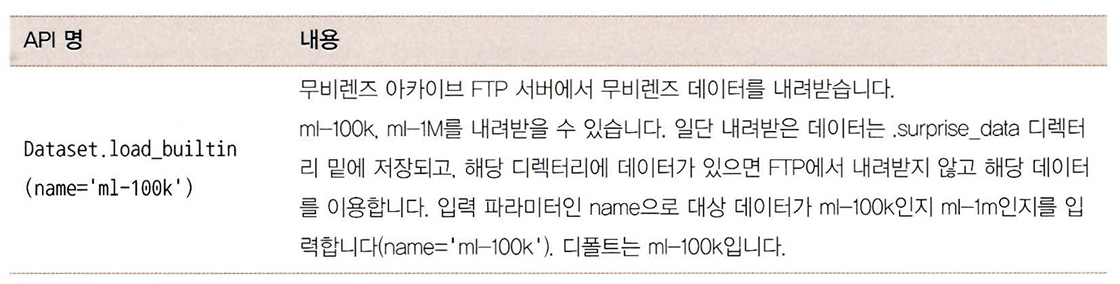


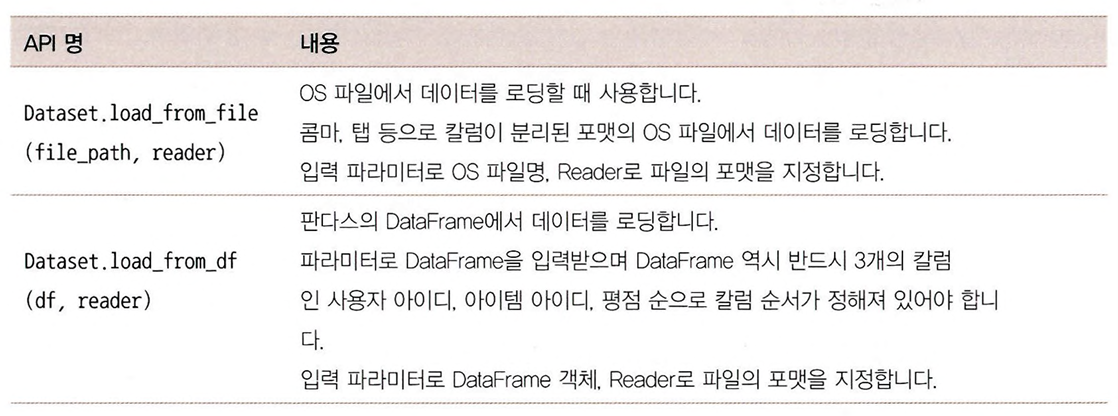

**OS 파일 데이터를 Surprise 데이터 세트로 로딩**

Surprise에 OS 파일을 로딩할 때의 주의할 점은 로딩되는 데이터 파일에 칼럼명을 가지는 헤더 문자열이 있어서는 안 된다는 것이다.

In [8]:
import pandas as pd

ratings = pd.read_csv('ratings.csv')
# ratings_noh.csv 파일로 언로드 시 인덱스와 헤더를 모두 제거한 새로운 파일 생성
ratings.to_csv('ratings_noh.csv', index=False, header=False)

Dataset으로 로드하기 전에 Reader 클래스를 이용해 데이터 파일의 파싱 포맷을 정의해야 한다. Reader 클래스는 로딩될 ratings_noh.csv 파일의 파싱 정보를 알려주기 위해 사용된다.

In [9]:
from surprise import Reader
reader = Reader(line_format='user item rating timestamp', sep=',',rating_scale=(0.5,5))
data = Dataset.load_from_file('ratings_noh.csv', reader=reader)

Reader 클래스의 주요 생성 파라미터는 다음과 같다.
- **line_format (string)**: 칼럼을 순서대로 나열한다. 입력된 문자열을 공백으로 분리해 칼럼으로 인식한다.
- **sep (char)**: 칼럼을 분리하는 분리자이며, 디폴트는 '\t' 이다. 판다스 DataFrame에서 입력받을 경우에는 기재할 필요가 없다.
- **rating_scale (tupe, optional)**: 평점 값의 최소 ~ 최대 평점을 설정한다.

In [10]:
trainset, testset = train_test_split(data, test_size=.25, random_state=0)

# 수행 시마다 동일한 결과를 도출하기 위해 random_state 설정
algo = SVD(n_factors=50, random_state=0)

# 학습 데이터로 학습하고 테스트 데이터로 평점 예측 후 RMSE 평가
algo.fit(trainset)
predictions = algo.test(testset)
accuracy.rmse(predictions)

RMSE: 0.8682


0.8681952927143516

**판다스 DataFrame에서 Surprise 데이터 세트로 로딩**

In [11]:
import pandas as pd
from surprise import Reader, Dataset

ratings = pd.read_csv('ratings.csv')
reader = Reader(rating_scale=(0.5,5.0))

# ratings DataFrame에서 칼럼은 사용자 아이디, 아이템 아이디, 평점 순서를 지켜야 한다.
data = Dataset.load_from_df(ratings[['userId','movieId','rating']],reader)
trainset, testset = train_test_split(data, test_size=.25, random_state=0)

algo = SVD(n_factors=50, random_state=0)
algo.fit(trainset)
predictions = algo.test(testset)
accuracy.rmse(predictions)

RMSE: 0.8682


0.8681952927143516

### **Surprise 추천 알고리즘 클래스**
Surprise에서 추천 예측을 위해 자주 사용되는 추천 알고리즘 클래스는 다음과 같다.

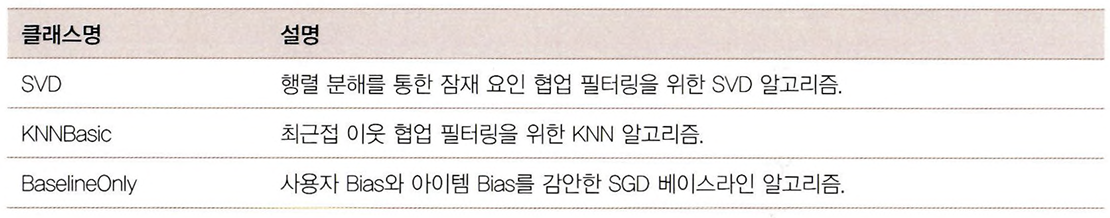

SVD 클래스의 입력 파라미터는 다음과 같다. biased의 경우는 큰 이슈가 없는 한 디폴트인 True로 설정을 유지하는 것이 좋다.

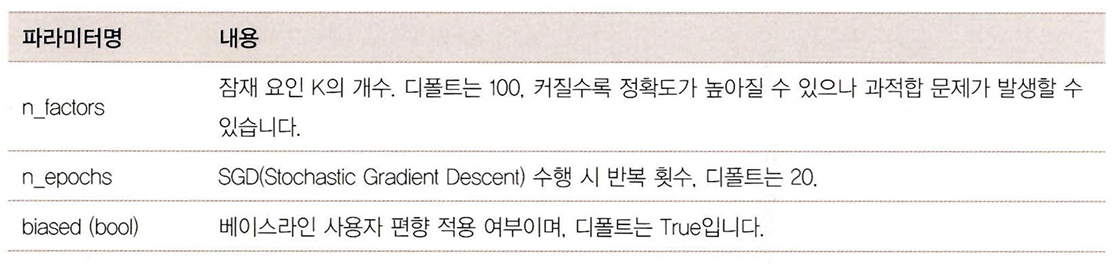

추천 알고리즘의 예측 성능 벤치마크 결과는 다음과 같다.

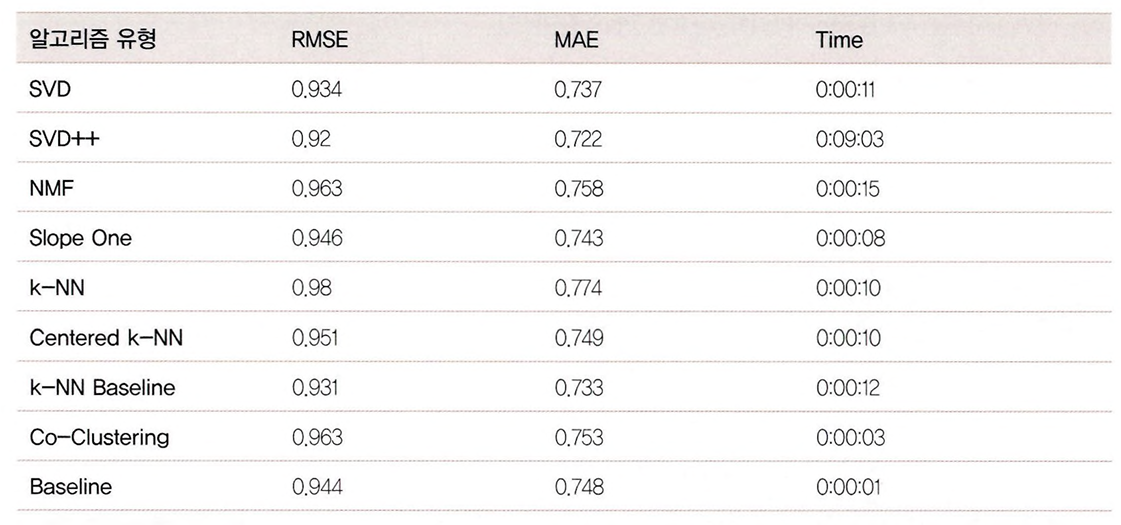

### **베이스라인 평점**
개인의 성향을 반영해 아이템 평가에 편향성 요소를 반영하여 평점을 부과하는 것을 베이스라인 평점 이라고 한다.

보통 베이스라인 평점은 전체 평균 평점 + 사용자 편향 점수 + 아이템 편향 점수 공식으로 계산된다.

- 전체 평균 평점 = 모든 사용자의 아이템에 대한 평점을 평균한 값
- 사용잠 편향 점수 = 사용자별 아이템 평점 평균 값 - 전체 평균 평점
- 아이템 편향 점수 = 아이템별 평점 평균 값 - 전체 평균 평점


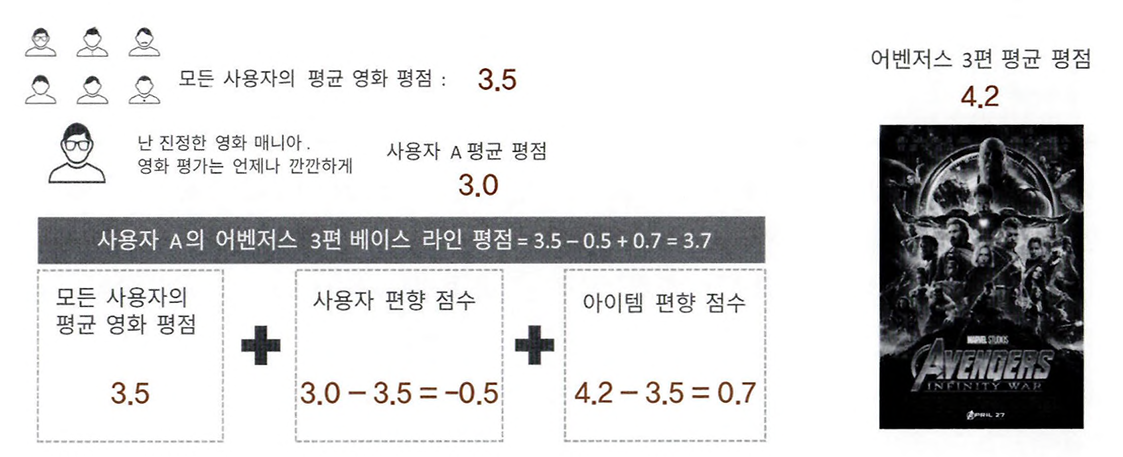

### **교차 검증과 하이퍼 파라미터 튜닝**
Surprise는 교차 검증과 하이퍼 파라미터 튜닝을 위해 사이킷런과 유사한 cross_validate( )와 GirdSearchCV 클래스를 제공한다.

In [12]:
from surprise.model_selection import cross_validate

# 판다스 DataFrame에서 Surprise 데이터 세트로 데이터 로딩
ratings = pd.read_csv('ratings.csv')
reader = Reader(rating_scale=(0.5,5.0))
data = Dataset.load_from_df(ratings[['userId','movieId','rating']],reader)

algo = SVD(random_state=0)
cross_validate(algo, data, measures=['RMSE','MAE'],cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8655  0.8724  0.8695  0.8748  0.8825  0.8729  0.0057  
MAE (testset)     0.6645  0.6710  0.6682  0.6725  0.6770  0.6706  0.0042  
Fit time          3.03    1.51    1.52    1.55    1.58    1.84    0.60    
Test time         0.26    0.12    0.27    0.12    0.40    0.23    0.11    


{'test_rmse': array([0.8654557 , 0.87240129, 0.86953226, 0.87480903, 0.88247689]),
 'test_mae': array([0.66451985, 0.67097338, 0.66818399, 0.672481  , 0.67701655]),
 'fit_time': (3.0347955226898193,
  1.5104718208312988,
  1.521862506866455,
  1.5452404022216797,
  1.583235740661621),
 'test_time': (0.25885772705078125,
  0.11614489555358887,
  0.2737736701965332,
  0.12176322937011719,
  0.4002721309661865)}

In [13]:
from surprise.model_selection import GridSearchCV

# 최적화할 파라미터를 딕셔너리 형태로 지정.
param_grid = {'n_epochs': [20, 40, 60], 'n_factors': [50, 100, 200] }

# CV를 3개 폴드 세트로 지정, 성능 평가는 rmse, mse로 수행하도록 GridSearchCV 구성
gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3)
gs.fit(data)

# 최고 RMSE Evaluation 점수와 그때의 하이퍼 파라미터
print(gs.best_score['rmse'])
print(gs.best_params['rmse'])

0.877144423946397
{'n_epochs': 20, 'n_factors': 50}


### **Surprise를 이용한 개인화 영화 추천 시스템 구축**


In [14]:
# 다음 코드는 train_test_split( )으로 분리되지 않는 데이터 세트에 fit( )을 호출해 오류가 발생합니다.
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
algo = SVD(n_factors=50, random_state=0)
algo.fit(data)

AttributeError: 'DatasetAutoFolds' object has no attribute 'n_users'

데이터 세트 전체를 학습 데이터로 사용하려면 DatasetAutoFolds 클래스를 이용하면 된다.

In [15]:
from surprise.dataset import DatasetAutoFolds

reader = Reader(line_format='user item rating timestamp', sep=',', rating_scale=(0.5,5))
# DatasetAutoFolds 클래스를 ratings_noh.csv 파일 기반으로 생성.
data_folds = DatasetAutoFolds(ratings_file='ratings_noh.csv', reader=reader)

# 전체 데이터를 학습 데이터로 생성함.
trainset = data_folds.build_full_trainset()

build_full_trainset( ) 메서드를 이용해 생성된 학습 데이터를 기반으로 학습을 수행한다. 그리고 이후에 특정 사용자에 영화를 추쳔하기 위해 아직 보지 않은 영화 목록을 확인한다.

In [16]:
algo = SVD(n_epochs=20, n_factors=50, random_state=0)
algo.fit(trainset)

In [17]:
# 영화에 대한 상세 속성 정보 DataFrame 로딩
movies = pd.read_csv('movies.csv')

# userId=9의 movieId 데이터를 추출해 movieId=42 데이터가 있는지 확인
movieIds = ratings[ratings['userId']==9]['movieId']

if movieIds[movieIds == 42].count == 0:
    print('사용자 아이디 9는 영화 아이디 42의 평점 없음')

print(movies[movies['movieId']==42])

    movieId                   title              genres
38       42  Dead Presidents (1995)  Action|Crime|Drama


In [18]:
uid = str(9)
iid = str(42)

pred = algo.predict(uid, iid, verbose=True)

user: 9          item: 42         r_ui = None   est = 3.13   {'was_impossible': False}


사용자가 평점을 매기지 않은 전체 영화를 추출한 뒤에 예측 평점 순으로 영화를 추천한다.

먼저 추천 대상이 되는 영화를 추출한 후, 새롭게 get_unseen_surprise( ) 함수를 만들어 이를 이용해 아이디 9인 사용자가 아직 평점을 매기지 않은 영화 정보를 반환한다.

In [19]:
def get_unseen_surprise(ratings, movies, userId):
    # 입력값으로 들어온 userId가 평점을 매긴 영화 목록
    seen_movies = ratings[ratings['userId'] == userId]['movieId'].tolist()

    # 모든 영화의 movieId 목록
    total_movies = movies['movieId'].tolist()

    # 이미 평점 매긴 영화 제외
    unseen_movies = [movie for movie in total_movies if movie not in seen_movies]

    print('평점 매긴 영화 수:', len(seen_movies),
          '추천 대상 영화 수:', len(unseen_movies),
          '전체 영화 수:', len(total_movies))

    return unseen_movies

# 예시: userId가 9인 경우
unseen_movies = get_unseen_surprise(ratings, movies, 9)

평점 매긴 영화 수: 46 추천 대상 영화 수: 9696 전체 영화 수: 9742


In [20]:
def recomm_movie_by_surprise(algo, userId, unseen_movies, movies, top_n=10):
    # 알고리즘 객체의 predict 메서드를 평점이 없는 영화에 반복 수행
    predictions = [algo.predict(str(userId), str(movieId)) for movieId in unseen_movies]

    # est 값을 기준으로 정렬
    def sortkey_est(pred):
        return pred.est

    predictions.sort(key=sortkey_est, reverse=True)
    top_predictions = predictions[:top_n]

    # top_n으로 추출된 영화 정보
    top_movie_ids = [int(pred.iid) for pred in top_predictions]
    top_movie_rating = [pred.est for pred in top_predictions]
    top_movie_titles = movies[movies.movieId.isin(top_movie_ids)]['title'].tolist()

    top_movie_preds = [(id, title, rating) for id, title, rating in zip(top_movie_ids, top_movie_titles, top_movie_rating)]
    return top_movie_preds

# unseen_movies 생성
unseen_movies = get_unseen_surprise(ratings, movies, 9)

# 추천 수행
top_movie_preds = recomm_movie_by_surprise(algo, 9, unseen_movies, movies, top_n=10)

# 결과 출력
print('##### Top-10 추천 영화 리스트 #####')
for top_movie in top_movie_preds:
    print(top_movie[1], ":", round(top_movie[2], 2))

평점 매긴 영화 수: 46 추천 대상 영화 수: 9696 전체 영화 수: 9742
##### Top-10 추천 영화 리스트 #####
Usual Suspects, The (1995) : 4.31
Star Wars: Episode IV - A New Hope (1977) : 4.28
Pulp Fiction (1994) : 4.28
Silence of the Lambs, The (1991) : 4.23
Godfather, The (1972) : 4.19
Streetcar Named Desire, A (1951) : 4.15
Star Wars: Episode V - The Empire Strikes Back (1980) : 4.12
Star Wars: Episode VI - Return of the Jedi (1983) : 4.11
Goodfellas (1990) : 4.08
Glory (1989) : 4.08


## **정리**
추천 시스템은 기업 애플리케이션에서 매우 중요한 위치를 차지하고 있다.

이번 장에서는 추천 시스템의 대표적인 방식인 콘텐츠 기반 필터링과 협업 필터링을 살펴보았다. 협업 필터링은 최근접 이웃 협업 필터링과 잠재 요인 협업 필터링으로 나뉜다. 잠재 요인 협업 필터링은 많은 추천 시스템에서 활용하는 방식이다. Surprise는 사이킷런과 유사한 API를 지향하며, 간단한 API만을 이용해 파이썬 기반에서 추천 시스템을 구현한다.